In [ ]:
# ============================================================
# 06_03_sector_models.ipynb
# Sector-Level SARIMA Forecasting
# ============================================================

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.config import DIR_DB_SILVER
from src.utils.m_query_database import f_query_database

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")


# ============================================================
# LOAD SILVER DATA
# ============================================================

query = 'SELECT * FROM "80072ned_silver"'

df = f_query_database(
    db_path=DIR_DB_SILVER,
    query=query,
    return_type="pandas"
)


# ============================================================
# TARGET CLEANING
# ============================================================

TARGET_COL = "Ziekteverzuimpercentage_1"

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)


# ============================================================
# CBS PERIODEN → TEMPORAL FEATURES
# ============================================================

# ------------------------------------------------------------
# Determine observation frequency
# ------------------------------------------------------------

df["frequency"] = np.select(
    [
        df["Perioden"].str.contains("KW", na=False),
        df["Perioden"].str.contains("MM", na=False),
        df["Perioden"].str.contains("JJ", na=False),
    ],
    [
        "quarterly",
        "monthly",
        "annual",
    ],
    default="unknown"
)


# ------------------------------------------------------------
# Extract year
# ------------------------------------------------------------

df["year"] = pd.to_numeric(
    df["Perioden"].str[:4],
    errors="coerce"
)


# ------------------------------------------------------------
# Extract quarter
# ------------------------------------------------------------

df["quarter"] = (
    df["Perioden"]
    .str.extract(r"KW(\d{2})")[0]
)

df["quarter"] = pd.to_numeric(
    df["quarter"],
    errors="coerce"
)


# ------------------------------------------------------------
# Create period_enddate
# ------------------------------------------------------------

df["period_enddate"] = pd.NaT


# Quarterly dates
mask_q = df["frequency"] == "quarterly"

df.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex.from_fields(
        year=df.loc[mask_q, "year"].astype(int),
        quarter=df.loc[mask_q, "quarter"].astype(int),
        freq="Q"
    )
    .to_timestamp(how="end")
)


# Annual dates
mask_y = df["frequency"] == "annual"

df.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df.loc[mask_y, "year"].astype(int).astype(str) + "-12-31"
)


# ------------------------------------------------------------
# Clean timestamp precision
# ------------------------------------------------------------

df["period_enddate"] = (
    pd.to_datetime(df["period_enddate"])
    .dt.normalize()
)


# ============================================================
# KEEP ONLY QUARTERLY OBSERVATIONS
# ============================================================

df = (
    df[df["frequency"] == "quarterly"]
    .copy()
)


# ============================================================
# QUICK DATA INSPECTION
# ============================================================

print("Shape:", df.shape)

print("\nDate Range:")
print(df["period_enddate"].min())
print(df["period_enddate"].max())

print("\nMissing Target Values:")
print(df[TARGET_COL].isna().sum())

display(df.head())

✅ Query returned 5850 rows from silver_data.db as pandas DataFrame


Shape: (4680, 17)

Date Range:
1996-03-31 00:00:00
2025-12-31 00:00:00

Missing Target Values:
248


,silver_id,bronze_pk,ID,BedrijfskenmerkenSBI2008,Perioden,Ziekteverzuimpercentage_1,_source_file,BedrijfskenmerkenSBI2008_Title,BedrijfskenmerkenSBI2008_Description,BedrijfskenmerkenSBI2008_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,frequency,year,quarter,period_enddate
0,1,TypedDataSet.json_0,0,T001081,1996KW01,5.5,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 1e kwartaal,,Definitief,quarterly,1996,1.0,1996-03-31
1,2,TypedDataSet.json_1,1,T001081,1996KW02,4.6,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 2e kwartaal,,Definitief,quarterly,1996,2.0,1996-06-30
2,3,TypedDataSet.json_2,2,T001081,1996KW03,4.0,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 3e kwartaal,,Definitief,quarterly,1996,3.0,1996-09-30
3,4,TypedDataSet.json_3,3,T001081,1996KW04,4.7,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1996 4e kwartaal,,Definitief,quarterly,1996,4.0,1996-12-31
5,6,TypedDataSet.json_5,5,T001081,1997KW01,4.9,TypedDataSet.json,A-U Alle economische activiteiten,Alle economische activiteiten \r\nDeze categor...,1,1997 1e kwartaal,,Definitief,quarterly,1997,1.0,1997-03-31


In [3]:
# ============================================================
# SECTOR OVERVIEW
# ============================================================

sector_summary = (
    df.groupby(
        [
            "BedrijfskenmerkenSBI2008",
            "BedrijfskenmerkenSBI2008_Title"
        ]
    )
    .agg(
        n_obs=(
            TARGET_COL,
            "count"
        ),

        missing_target=(
            TARGET_COL,
            lambda x: x.isna().sum()
        ),

        first_date=(
            "period_enddate",
            "min"
        ),

        last_date=(
            "period_enddate",
            "max"
        ),

        mean_absenteeism=(
            TARGET_COL,
            "mean"
        )
    )
    .reset_index()
)

# ============================================================
# SORT BY OBSERVATION COUNT
# ============================================================

sector_summary = sector_summary.sort_values(
    "n_obs",
    ascending=False
)

print("Number of sectors:")
print(sector_summary.shape[0])

display(
    sector_summary.head(20)
)

Number of sectors:
39


,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title,n_obs,missing_target,first_date,last_date,mean_absenteeism
0,300003,B-F Nijverheid en energie,120,0,1996-03-31,2025-12-31,5.184167
1,300007,G-N Commerciële dienstverlening,120,0,1996-03-31,2025-12-31,3.819167
2,300013,O-U Niet-commerciële dienstverlening,120,0,1996-03-31,2025-12-31,5.655833
3,301000,"A Landbouw, bosbouw en visserij",120,0,1996-03-31,2025-12-31,2.976667
4,305700,B Delfstoffenwinning,120,0,1996-03-31,2025-12-31,3.732500
5,307500,C Industrie,120,0,1996-03-31,2025-12-31,5.585833
6,307610,"10-12 Voedings-, genotmiddelenindustrie",120,0,1996-03-31,2025-12-31,5.017500
8,320005,19-22 Raffinaderijen en chemie,120,0,1996-03-31,2025-12-31,4.953333
9,328110,"24-30, 33 Metaal-elektro industrie",120,0,1996-03-31,2025-12-31,4.675000
13,354200,G Handel,120,0,1996-03-31,2025-12-31,3.721667


In [4]:
# ============================================================
# KEEP ONLY PRIMARY SBI SECTORS
# ============================================================

primary_sector_mask = (
    df["BedrijfskenmerkenSBI2008_Title"]
    .str.match(r"^[A-S]\s")
)

df_sectors = (
    df[primary_sector_mask]
    .copy()
)

# ============================================================
# VALIDATE
# ============================================================

sector_list = (
    df_sectors[
        [
            "BedrijfskenmerkenSBI2008",
            "BedrijfskenmerkenSBI2008_Title"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "BedrijfskenmerkenSBI2008_Title"
    )
)

print("Number of primary sectors:")
print(sector_list.shape[0])

display(sector_list)

Number of primary sectors:
19


,BedrijfskenmerkenSBI2008,BedrijfskenmerkenSBI2008_Title
150,301000,"A Landbouw, bosbouw en visserij"
300,305700,B Delfstoffenwinning
600,307500,C Industrie
1350,346600,D Energievoorziening
1500,348000,E Waterbedrijven en afvalbeheer
1650,350000,F Bouwnijverheid
1950,354200,G Handel
2550,383100,H Vervoer en opslag
2850,389100,I Horeca
3000,391600,J Informatie en communicatie


(2280, 3)


,period_enddate,sector,absenteeism
150,1996-03-31,"A Landbouw, bosbouw en visserij",4.5
151,1996-06-30,"A Landbouw, bosbouw en visserij",3.8
152,1996-09-30,"A Landbouw, bosbouw en visserij",2.7
153,1996-12-31,"A Landbouw, bosbouw en visserij",3.2
155,1997-03-31,"A Landbouw, bosbouw en visserij",4.0


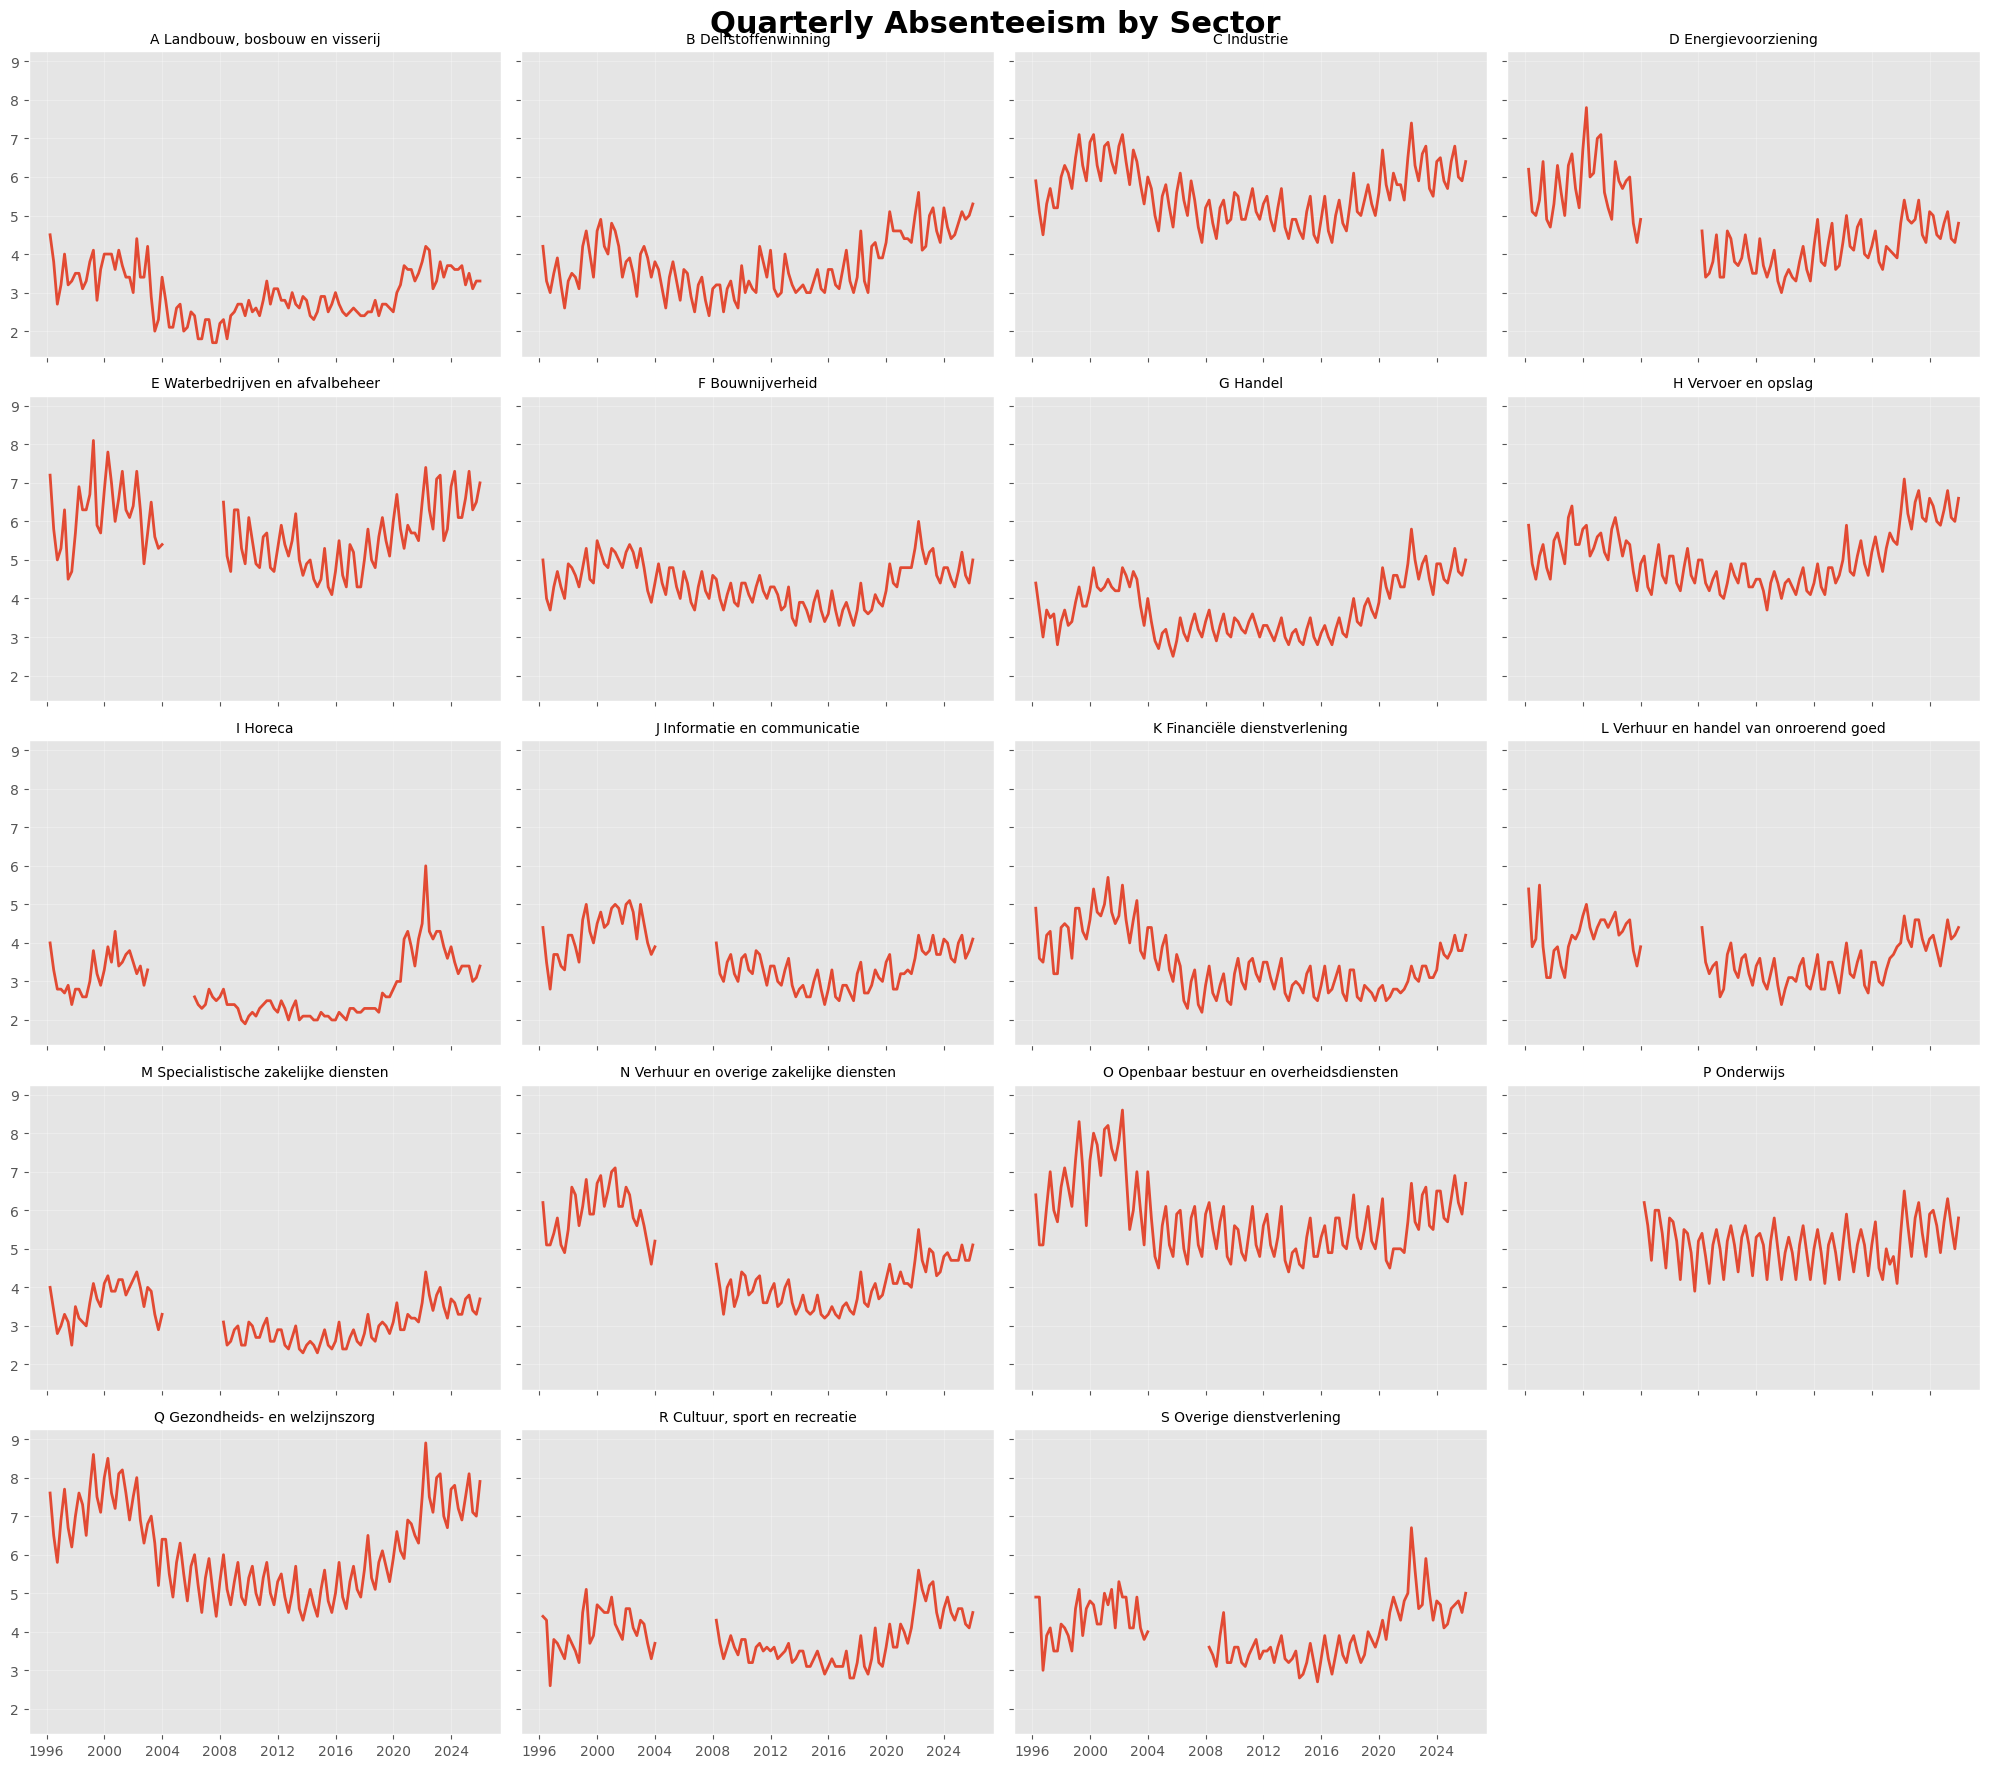

In [7]:
# ============================================================
# CREATE SECTOR TIME SERIES DATAFRAME
# ============================================================

df_sector_ts = (
    df_sectors[
        [
            "period_enddate",
            "BedrijfskenmerkenSBI2008_Title",
            TARGET_COL
        ]
    ]
    .copy()
)

# ============================================================
# RENAME COLUMNS
# ============================================================

df_sector_ts = df_sector_ts.rename(columns={
    "BedrijfskenmerkenSBI2008_Title": "sector",
    TARGET_COL: "absenteeism"
})

# ============================================================
# SORT
# ============================================================

df_sector_ts = df_sector_ts.sort_values(
    [
        "sector",
        "period_enddate"
    ]
)

# ============================================================
# QUICK VALIDATION
# ============================================================

print(df_sector_ts.shape)

display(df_sector_ts.head())

# ============================================================
# SMALL MULTIPLE SECTOR PLOTS
# ============================================================

sectors = sorted(
    df_sector_ts["sector"].unique()
)

# ------------------------------------------------------------
# CREATE SUBPLOTS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20, 18),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# ============================================================
# PLOT EACH SECTOR
# ============================================================

for i, sector in enumerate(sectors):

    ax = axes[i]

    df_plot = (
        df_sector_ts[
            df_sector_ts["sector"] == sector
        ]
    )

    ax.plot(
        df_plot["period_enddate"],
        df_plot["absenteeism"],
        linewidth=2
    )

    ax.set_title(
        sector,
        fontsize=10
    )

    ax.grid(True, alpha=0.3)

# ============================================================
# REMOVE EMPTY SUBPLOTS
# ============================================================

for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# GLOBAL FORMATTING
# ============================================================

fig.suptitle(
    "Quarterly Absenteeism by Sector",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [8]:
# ============================================================
# KEEP ONLY 2010+
# ============================================================

df_sector_ts = (
    df_sector_ts[
        df_sector_ts["period_enddate"] >= "2010-01-01"
    ]
    .copy()
)

# ============================================================
# VALIDATION
# ============================================================

print(df_sector_ts.shape)

print(
    df_sector_ts["period_enddate"].min()
)

print(
    df_sector_ts["period_enddate"].max()
)

(1216, 3)
2010-03-31 00:00:00
2025-12-31 00:00:00


In [9]:
# ============================================================
# FINAL COMPLETENESS CHECK
# ============================================================

sector_validation = (
    df_sector_ts
    .groupby("sector")
    .agg(
        n_quarters=(
            "period_enddate",
            "nunique"
        ),

        missing_values=(
            "absenteeism",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

display(sector_validation)

,sector,n_quarters,missing_values
0,"A Landbouw, bosbouw en visserij",64,0
1,B Delfstoffenwinning,64,0
2,C Industrie,64,0
3,D Energievoorziening,64,0
4,E Waterbedrijven en afvalbeheer,64,0
5,F Bouwnijverheid,64,0
6,G Handel,64,0
7,H Vervoer en opslag,64,0
8,I Horeca,64,0
9,J Informatie en communicatie,64,0


In [10]:
# ============================================================
# ROLLING SARIMA FORECASTING — ALL SECTORS
# ============================================================

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

INITIAL_TRAIN_SIZE = 40
FORECAST_HORIZON = 1

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

sector_results = []

future_forecasts = []

# ============================================================
# LOOP THROUGH SECTORS
# ============================================================

for sector in sorted(df_sector_ts["sector"].unique()):

    print(f"\nProcessing: {sector}")

    # --------------------------------------------------------
    # FILTER SECTOR
    # --------------------------------------------------------

    df_sector = (
        df_sector_ts[
            df_sector_ts["sector"] == sector
        ]
        .sort_values("period_enddate")
        .copy()
    )

    # --------------------------------------------------------
    # CREATE TIME SERIES
    # --------------------------------------------------------

    ts = pd.Series(
        df_sector["absenteeism"].values,
        index=df_sector["period_enddate"]
    )

    # --------------------------------------------------------
    # ROLLING FORECAST STORAGE
    # --------------------------------------------------------

    actuals = []
    forecasts = []
    dates = []

    # ========================================================
    # ROLLING FORECAST LOOP
    # ========================================================

    for i in range(
        INITIAL_TRAIN_SIZE,
        len(ts)
    ):

        train = ts.iloc[:i]

        test = ts.iloc[i]

        try:

            # ------------------------------------------------
            # FIT SARIMA
            # ------------------------------------------------

            model = SARIMAX(
                train,
                order=(1, 1, 1),
                seasonal_order=(1, 0, 1, 4),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(
                disp=False
            )

            # ------------------------------------------------
            # FORECAST NEXT QUARTER
            # ------------------------------------------------

            pred = fitted.forecast(1).iloc[0]

            # ------------------------------------------------
            # STORE
            # ------------------------------------------------

            actuals.append(test)

            forecasts.append(pred)

            dates.append(ts.index[i])

        except Exception as e:

            print(
                f"Failed at {sector} | index {i}"
            )

    # ========================================================
    # METRICS
    # ========================================================

    mae = mean_absolute_error(
        actuals,
        forecasts
    )

    rmse = np.sqrt(
        mean_squared_error(
            actuals,
            forecasts
        )
    )

    mape = np.mean(
        np.abs(
            (
                np.array(actuals)
                - np.array(forecasts)
            )
            / np.array(actuals)
        )
    ) * 100

    # --------------------------------------------------------
    # STORE METRICS
    # --------------------------------------------------------

    sector_results.append({
        "sector": sector,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

    # ========================================================
    # FINAL 4-QUARTER FORECAST
    # ========================================================

    final_model = SARIMAX(
        ts,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 4),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    final_fit = final_model.fit(
        disp=False
    )

    future_pred = final_fit.forecast(4)

    # --------------------------------------------------------
    # STORE FUTURE FORECASTS
    # --------------------------------------------------------

    future_forecasts.append(
        pd.DataFrame({
            "sector": sector,
            "date": future_pred.index,
            "forecast": future_pred.values
        })
    )

# ============================================================
# FINAL RESULTS TABLES
# ============================================================

sector_results_df = pd.DataFrame(
    sector_results
)

sector_results_df = (
    sector_results_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)

future_forecasts_df = pd.concat(
    future_forecasts,
    ignore_index=True
)

# ============================================================
# ROUND
# ============================================================

sector_results_df = (
    sector_results_df.round(3)
)

future_forecasts_df["forecast"] = (
    future_forecasts_df["forecast"]
    .round(3)
)

# ============================================================
# DISPLAY
# ============================================================

print("\nMODEL PERFORMANCE")

display(sector_results_df)

print("\nFUTURE FORECASTS")

display(future_forecasts_df.head(20))


Processing: A Landbouw, bosbouw en visserij

Processing: B Delfstoffenwinning

Processing: C Industrie

Processing: D Energievoorziening

Processing: E Waterbedrijven en afvalbeheer

Processing: F Bouwnijverheid

Processing: G Handel

Processing: H Vervoer en opslag

Processing: I Horeca

Processing: J Informatie en communicatie

Processing: K Financiële dienstverlening

Processing: L Verhuur en handel van onroerend goed

Processing: M Specialistische zakelijke diensten

Processing: N Verhuur en overige zakelijke diensten

Processing: O Openbaar bestuur en overheidsdiensten

Processing: P Onderwijs

Processing: Q Gezondheids- en welzijnszorg

Processing: R Cultuur, sport en recreatie

Processing: S Overige dienstverlening

MODEL PERFORMANCE


,sector,MAE,RMSE,MAPE
0,K Financiële dienstverlening,0.151,0.208,4.544
1,J Informatie en communicatie,0.176,0.228,4.942
2,M Specialistische zakelijke diensten,0.188,0.252,5.286
3,F Bouwnijverheid,0.221,0.263,4.452
4,H Vervoer en opslag,0.196,0.274,3.250
5,G Handel,0.233,0.285,4.903
6,L Verhuur en handel van onroerend goed,0.224,0.292,5.650
7,D Energievoorziening,0.215,0.299,4.687
8,N Verhuur en overige zakelijke diensten,0.223,0.303,4.759
9,O Openbaar bestuur en overheidsdiensten,0.283,0.361,5.057



FUTURE FORECASTS


,sector,date,forecast
0,"A Landbouw, bosbouw en visserij",2026-03-31,3.331
1,"A Landbouw, bosbouw en visserij",2026-06-30,3.305
2,"A Landbouw, bosbouw en visserij",2026-09-30,3.320
3,"A Landbouw, bosbouw en visserij",2026-12-31,3.326
4,B Delfstoffenwinning,2026-03-31,5.456
5,B Delfstoffenwinning,2026-06-30,4.953
6,B Delfstoffenwinning,2026-09-30,4.850
7,B Delfstoffenwinning,2026-12-31,5.358
8,C Industrie,2026-03-31,6.887
9,C Industrie,2026-06-30,6.090


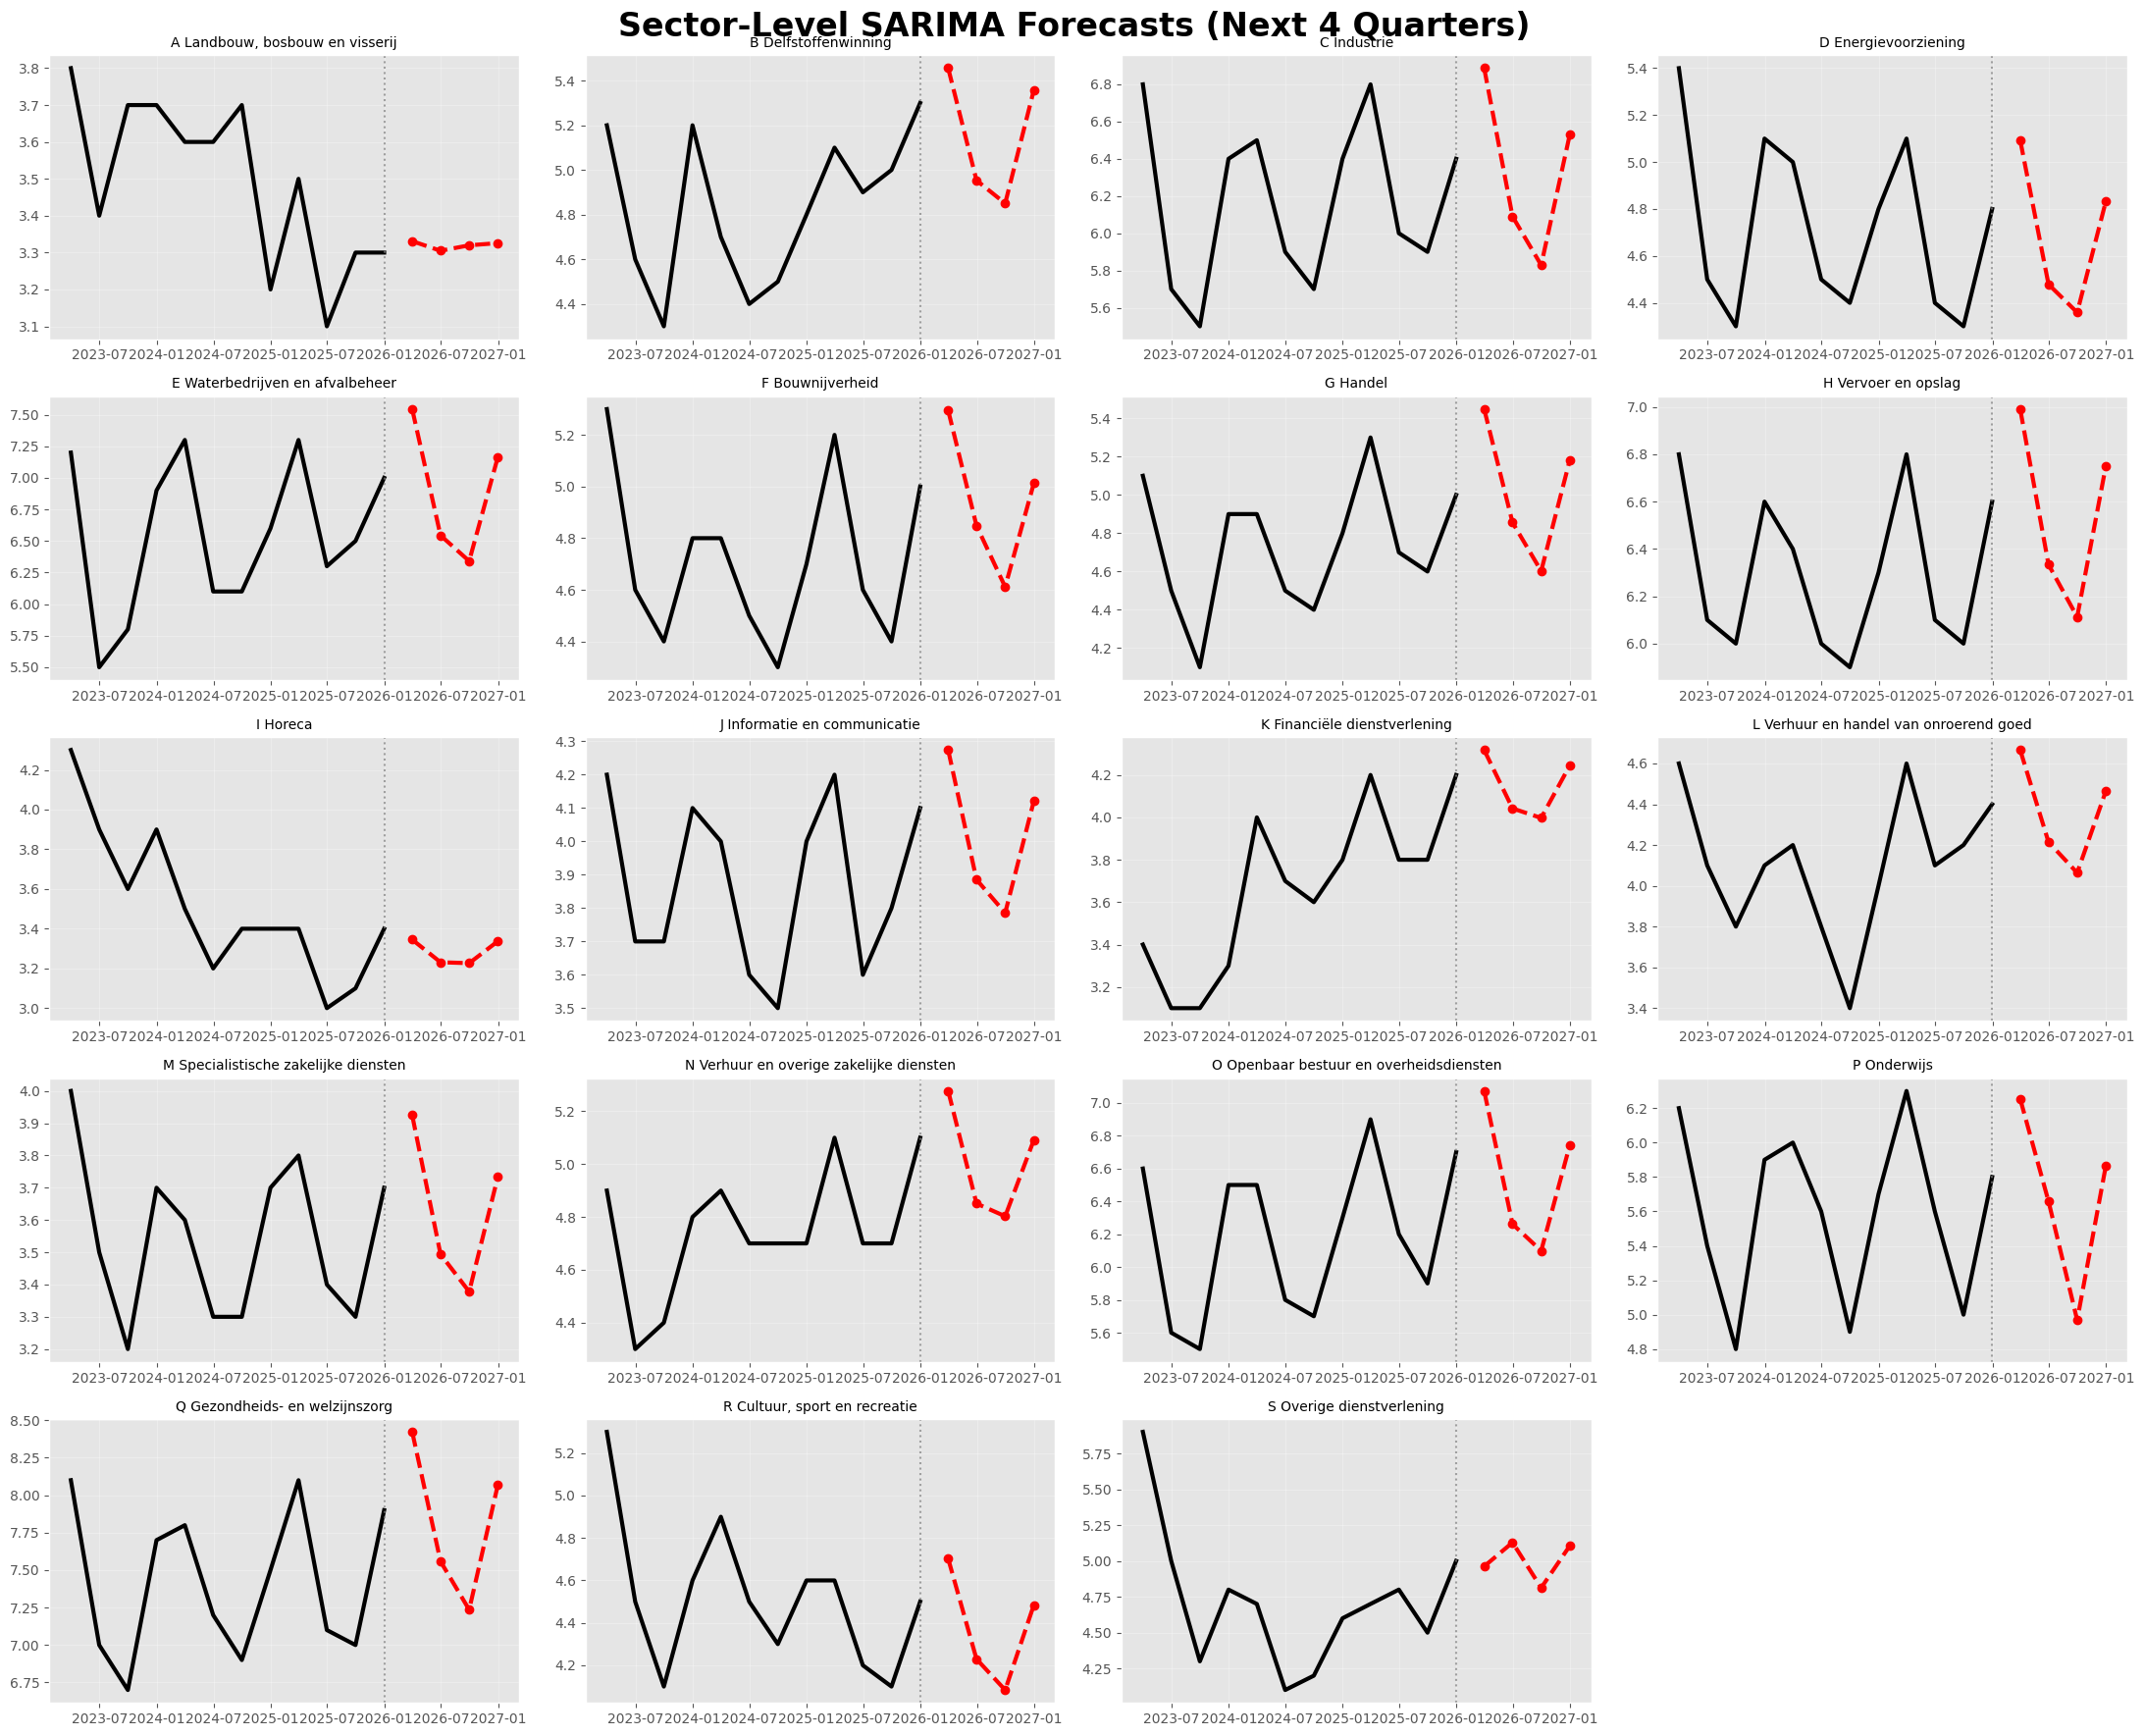

In [11]:
# ============================================================
# CREATE FULL FORECAST TRAJECTORY DATA
# ============================================================

forecast_plot_data = []

# ============================================================
# LOOP THROUGH SECTORS
# ============================================================

for sector in sorted(df_sector_ts["sector"].unique()):

    # --------------------------------------------------------
    # FILTER SECTOR
    # --------------------------------------------------------

    df_sector = (
        df_sector_ts[
            df_sector_ts["sector"] == sector
        ]
        .sort_values("period_enddate")
        .copy()
    )

    # --------------------------------------------------------
    # CREATE TIME SERIES
    # --------------------------------------------------------

    ts = pd.Series(
        df_sector["absenteeism"].values,
        index=df_sector["period_enddate"]
    )

    # --------------------------------------------------------
    # LAST HISTORICAL OBSERVATIONS
    # --------------------------------------------------------

    historical_tail = ts.iloc[-12:]

    historical_df = pd.DataFrame({
        "date": historical_tail.index,
        "value": historical_tail.values,
        "type": "Historical",
        "sector": sector
    })

    # ========================================================
    # FIT FINAL SARIMA MODEL
    # ========================================================

    model = SARIMAX(
        ts,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 4),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False
    )

    # --------------------------------------------------------
    # FORECAST NEXT 4 QUARTERS
    # --------------------------------------------------------

    future_pred = fitted.forecast(4)

    forecast_df = pd.DataFrame({
        "date": future_pred.index,
        "value": future_pred.values,
        "type": "Forecast",
        "sector": sector
    })

    # --------------------------------------------------------
    # COMBINE
    # --------------------------------------------------------

    combined = pd.concat(
        [
            historical_df,
            forecast_df
        ]
    )

    forecast_plot_data.append(combined)

# ============================================================
# FINAL DATAFRAME
# ============================================================

forecast_plot_df = pd.concat(
    forecast_plot_data,
    ignore_index=True
)

# ============================================================
# SMALL MULTIPLE FORECAST PLOTS
# ============================================================

sectors = sorted(
    forecast_plot_df["sector"].unique()
)

# ------------------------------------------------------------
# CREATE SUBPLOTS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(22, 18),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# ============================================================
# PLOT EACH SECTOR
# ============================================================

for i, sector in enumerate(sectors):

    ax = axes[i]

    df_plot = (
        forecast_plot_df[
            forecast_plot_df["sector"] == sector
        ]
    )

    # --------------------------------------------------------
    # HISTORICAL
    # --------------------------------------------------------

    hist = (
        df_plot[
            df_plot["type"] == "Historical"
        ]
    )

    ax.plot(
        hist["date"],
        hist["value"],
        linewidth=3,
        color="black",
        label="Historical"
    )

    # --------------------------------------------------------
    # FORECAST
    # --------------------------------------------------------

    forecast = (
        df_plot[
            df_plot["type"] == "Forecast"
        ]
    )

    ax.plot(
        forecast["date"],
        forecast["value"],
        linewidth=3,
        linestyle="--",
        marker="o",
        color="red",
        label="Forecast"
    )

    # --------------------------------------------------------
    # VERTICAL SPLIT
    # --------------------------------------------------------

    ax.axvline(
        x=hist["date"].max(),
        linestyle=":",
        color="gray",
        alpha=0.7
    )

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    ax.set_title(
        sector,
        fontsize=10
    )

    ax.grid(
        True,
        alpha=0.3
    )

# ============================================================
# REMOVE EMPTY SUBPLOTS
# ============================================================

for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# GLOBAL FORMATTING
# ============================================================

fig.suptitle(
    "Sector-Level SARIMA Forecasts (Next 4 Quarters)",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

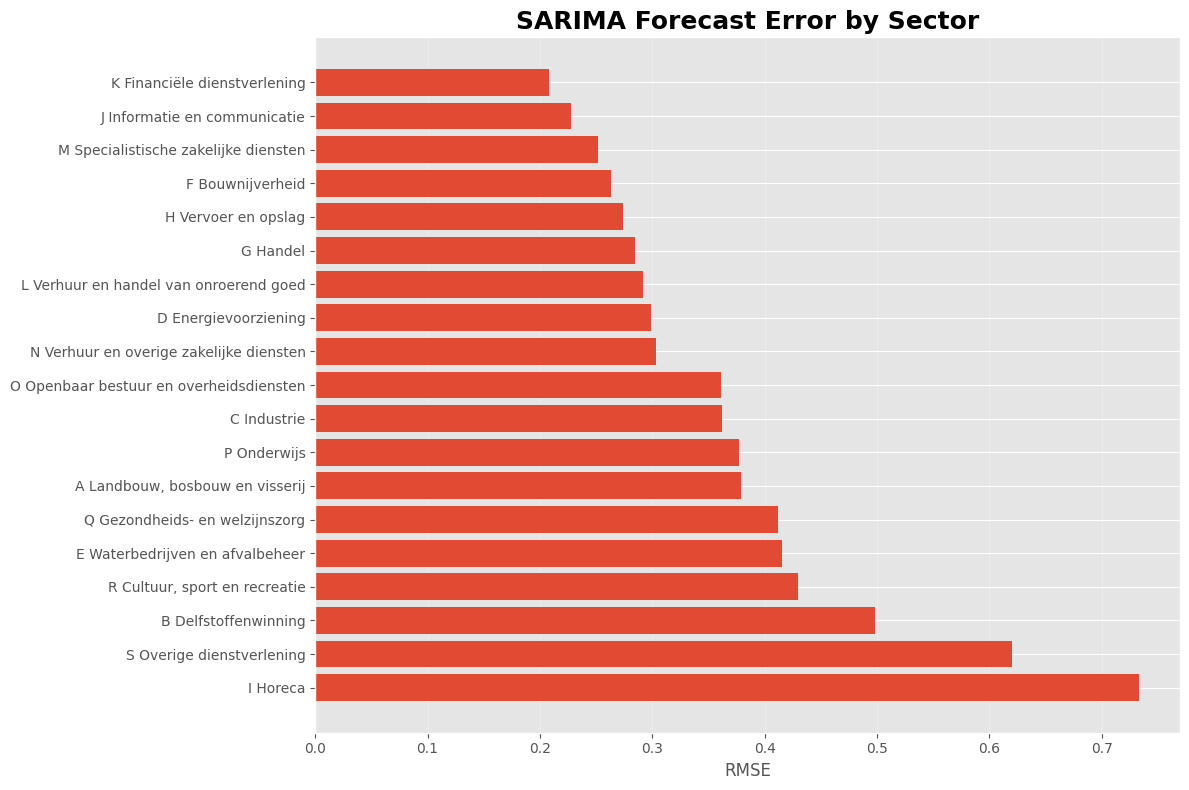

In [12]:
# ============================================================
# FORECAST ACCURACY BY SECTOR
# ============================================================

plot_df = (
    sector_results_df
    .sort_values("RMSE")
)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["sector"],
    plot_df["RMSE"]
)

plt.xlabel("RMSE")

plt.title(
    "SARIMA Forecast Error by Sector",
    fontsize=18,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Sector-Level SARIMA Forecasting (2010–2025)

Sector-level absenteeism forecasting was performed using quarterly CBS data for 19 primary Dutch economic sectors (A–S). To improve temporal consistency and avoid structural breaks caused by historical sector reclassifications, the analysis was restricted to the post-2010 period, resulting in 64 complete quarterly observations per sector without missing values.

A rolling one-step-ahead SARIMA forecasting strategy was implemented using a SARIMA(1,1,1)(1,0,1,4) specification, which previously showed strong performance in the national-level analysis. For each sector, the model was recursively retrained using expanding historical windows and evaluated on unseen future quarters.

The analysis revealed substantial differences in forecastability across sectors. Financial services, information & communication, and professional services achieved the lowest forecast errors, indicating stable and predictable absenteeism dynamics. In contrast, horeca, culture/recreation, and mining exhibited considerably higher forecasting errors, reflecting higher volatility and structural instability, particularly after COVID-19.

Sector-level forecast trajectories for the next four quarters (2026) were generated and visualized, showing clear differences in seasonal behavior, trend dynamics, and expected absenteeism levels across sectors. Healthcare and public sectors remained among the highest absenteeism sectors, while finance and information sectors remained relatively stable and lower.